<a href="https://colab.research.google.com/github/adity1234567/Play-Pause-Perform-Gaming-Habits-and-Student-Success/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets scikit-learn matplotlib seaborn plotly xgboost lightgbm catboost shap umap-learn scipy nbformat kaleido -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configure plotly for notebook display
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

from datasets import load_dataset
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             silhouette_score, davies_bouldin_score, calinski_harabasz_score)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Models for RQ1 (CGPA Prediction)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Models for RQ2 & RQ3 (Clustering)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture

import shap
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(" All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 1.6 MB/s eta 0:00:00
✅ All libraries imported successfully!


In [ ]:
# Cell 2: Load Dataset
print("Loading uniGame dataset from Hugging Face...")
dataset = load_dataset("ismail31415/uniGame")
df = pd.DataFrame(dataset['train'])


Loading uniGame dataset from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/791 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/198 [00:00<?, ? examples/s]

In [ ]:
print("Preprocessing data...")
df = df.dropna()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
target_col = 'CGPA' if 'CGPA' in df.columns else df.columns[-1]
feature_cols = [col for col in df.columns if col != target_col]

Preprocessing data...


In [ ]:
print(f"\nTarget Variable: {target_col}")
print(f"Features: {len(feature_cols)}")
print(f"   - Numeric: {len([c for c in feature_cols if c in numeric_cols])}")
print(f"   - Categorical: {len([c for c in feature_cols if c in categorical_cols])}")


Target Variable: Are you wearing glasses?
Features: 19
   - Numeric: 7
   - Categorical: 12


In [ ]:
# Encode categorical variables
df_encoded = df.copy()
le_dict = {}

In [ ]:
# First, encode all categorical features (excluding target
for col in categorical_cols:
    if col != target_col and col in feature_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

In [ ]:
# Handle target variable
if target_col in categorical_cols or df[target_col].dtype == 'object':
    print(f"\nTarget variable '{target_col}' is categorical. Encoding it...")
    le_target = LabelEncoder()
    df_encoded[target_col] = le_target.fit_transform(df[target_col].astype(str))
    le_dict[target_col] = le_target
    print(f"   Encoded classes: {list(le_target.classes_)}")
    df_encoded[target_col] = df_encoded[target_col].astype(np.float64)
else:
    df_encoded[target_col] = pd.to_numeric(df_encoded[target_col], errors='coerce')


Target variable 'Are you wearing glasses?' is categorical. Encoding it...
   Encoded classes: ['No', 'Yes']


In [ ]:
df_encoded = df_encoded.dropna(subset=[target_col])

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 20 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   What is your age?                                                     791 non-null    int64  
 1   Current educational position?                                         791 non-null    int64  
 2   Gender?                                                               791 non-null    int64  
 3   Your  current CGPA?                                                   791 non-null    float64
 4   Your Higher Secondary School(H. SC) or A level or equivalent result?  791 non-null    float64
 5   At what age you had started playing games?                            791 non-null    int64  
 6   Do you play games on mobile or pc?                                    791 non-null    int64  
 7  

In [ ]:
X = df_encoded[feature_cols].copy()
y = df_encoded[target_col].copy()


In [ ]:
for col in X.columns:
    if X[col].dtype == 'object':
        print(f"Converting remaining categorical column: {col}")
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        le_dict[col] = le

In [ ]:
X = X.astype(np.float64)
y = y.astype(np.float64)

In [ ]:
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)


In [ ]:
print(f"\nPreprocessing complete!")
print(f"   Feature matrix: {X.shape}, dtype: {X.dtypes.unique()}")
print(f"   Target vector: {y.shape}, dtype: {y.dtype}")
print(f"   Target range: [{y.min():.2f}, {y.max():.2f}]")
print(f"   Target unique values: {len(y.unique())}")


Preprocessing complete!
   Feature matrix: (791, 19), dtype: [dtype('float64')]
   Target vector: (791,), dtype: float64
   Target range: [0.00, 1.00]
   Target unique values: 2


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
print(f"Data Split Complete!")
print(f"   Training set: {X_train.shape}")
print(f"   Test set: {X_test.shape}")
print(f"   y_train dtype: {y_train.dtype}")
print(f"   y_test dtype: {y_test.dtype}")

Data Split Complete!
   Training set: (632, 19)
   Test set: (159, 19)
   y_train dtype: float64
   y_test dtype: float64


In [ ]:
# RQ1 - Multiple Regression Models for CGPA Prediction
print("RQ1: PREDICTING STUDENT CGPA WITH MULTIPLE MODELS")
print("-" * 80)

models = {
    'Linear Ridge': Ridge(alpha=1.0, random_state=42),
    'Linear Lasso': Lasso(alpha=0.1, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.1, random_state=42),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=5, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=5, random_state=42, verbosity=-1),
    'CatBoost': CatBoostRegressor(n_estimators=100, max_depth=5, random_state=42, verbose=0),
    'SVR': SVR(kernel='rbf', C=1.0),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    try:
        model.fit(X_train_scaled, y_train.values.ravel())
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)

        # Metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)

        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train.values.ravel(),
                                   cv=5, scoring='r2', error_score='raise')

        results.append({
            'Model': name,
            'Train R²': train_r2,
            'Test R²': test_r2,
            'Train RMSE': train_rmse,
            'Test RMSE': test_rmse,
            'Train MAE': train_mae,
            'Test MAE': test_mae,
            'CV R² Mean': cv_scores.mean(),
            'CV R² Std': cv_scores.std()
        })

        print(f"   Test R²: {test_r2:.4f} | Test RMSE: {test_rmse:.4f} | CV R²: {cv_scores.mean():.4f}±{cv_scores.std():.4f}")

    except Exception as e:
        print(f"    Error training {name}: {str(e)}")
        continue

results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False)
print("\n" + "-" * 80)
print(" MODEL PERFORMANCE SUMMARY (Sorted by Test R²)")
print("=" * 80)
print(results_df.to_string(index=False))

# best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n Best Model: {best_model_name} with Test R² = {results_df.iloc[0]['Test R²']:.4f}")

RQ1: PREDICTING STUDENT CGPA WITH MULTIPLE MODELS
--------------------------------------------------------------------------------

Training Linear Ridge...
   Test R²: 0.0483 | Test RMSE: 0.4875 | CV R²: -0.0232±0.0679

Training Linear Lasso...
   Test R²: -0.0023 | Test RMSE: 0.5003 | CV R²: -0.0146±0.0144

Training ElasticNet...
   Test R²: 0.0001 | Test RMSE: 0.4997 | CV R²: -0.0159±0.0141

Training Decision Tree...
   Test R²: 0.2695 | Test RMSE: 0.4271 | CV R²: 0.0864±0.2012

Training Random Forest...
   Test R²: 0.5946 | Test RMSE: 0.3182 | CV R²: 0.4230±0.0619

Training Gradient Boosting...
   Test R²: 0.6741 | Test RMSE: 0.2853 | CV R²: 0.4098±0.1003

Training AdaBoost...
   Test R²: 0.0784 | Test RMSE: 0.4798 | CV R²: -0.0531±0.0650

Training XGBoost...
   Test R²: 0.6793 | Test RMSE: 0.2830 | CV R²: 0.4466±0.1063

Training LightGBM...
   Test R²: 0.5088 | Test RMSE: 0.3503 | CV R²: 0.3414±0.0911

Training CatBoost...
   Test R²: 0.6180 | Test RMSE: 0.3089 | CV R²: 0.3946±0.0

In [ ]:
import plotly.io as pio
pio.renderers.default = "colab"


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [ ]:
if 'results_df' not in locals() or results_df.empty:
    print(" No results to visualize. Please run Cell 5 first.")
else:
    # Ensure nbformat is available for interactive plotly rendering
    try:
        import nbformat
    except ImportError:
        print("nbformat not found. Installing/Updating...")
        !pip install nbformat -U -q
        import nbformat
        print("nbformat installed/updated.")

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('R² Score Comparison', 'RMSE Comparison',
                        'MAE Comparison', 'Cross-Validation R² with Error Bars'),
        vertical_spacing=0.12,
        horizontal_spacing=0.1
    )

    # R² Score
    fig.add_trace(
        go.Bar(name='Train R²', x=results_df['Model'], y=results_df['Train R²'],
               marker_color='lightblue'),
        row=1, col=1
    )
    fig.add_trace(
        go.Bar(name='Test R²', x=results_df['Model'], y=results_df['Test R²'],
               marker_color='darkblue'),
        row=1, col=1
    )

    # RMSE
    fig.add_trace(
        go.Bar(name='Train RMSE', x=results_df['Model'], y=results_df['Train RMSE'],
               marker_color='lightcoral', showlegend=False),
        row=1, col=2
    )
    fig.add_trace(
        go.Bar(name='Test RMSE', x=results_df['Model'], y=results_df['Test RMSE'],
               marker_color='darkred', showlegend=False),
        row=1, col=2
    )

    # MAE
    fig.add_trace(
        go.Bar(name='Train MAE', x=results_df['Model'], y=results_df['Train MAE'],
               marker_color='lightgreen', showlegend=False),
        row=2, col=1
    )
    fig.add_trace(
        go.Bar(name='Test MAE', x=results_df['Model'], y=results_df['Test MAE'],
               marker_color='darkgreen', showlegend=False),
        row=2, col=1
    )

    # CV with error bars
    fig.add_trace(
        go.Scatter(
            name='CV R²',
            x=results_df['Model'],
            y=results_df['CV R² Mean'],
            error_y=dict(type='data', array=results_df['CV R² Std']),
            mode='markers+lines',
            marker=dict(size=10, color='purple'),
            showlegend=False
        ),
        row=2, col=2
    )

    fig.update_xaxes(tickangle=-45)
    fig.update_layout(
        height=800,
        title_text="RQ1: CGPA Prediction Model Performance Comparison",
        title_font_size=20,
        showlegend=True
    )

    # File paths for static plots
    rq1_model_comparison_file = "rq1_model_comparison.html"
    rq1_predictions_file = "rq1_predictions.html"

    try:
        fig.show()
    except Exception as e:
        print(f" Could not display interactive plot: {e}")
        print(f"Saving as static image instead to {rq1_model_comparison_file}...")
        fig.write_html(rq1_model_comparison_file)
        print(f" Plot saved as '{rq1_model_comparison_file}'")

    # Actual vs Predicted for Best Model
    y_pred_best = best_model.predict(X_test_scaled)

    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(
        x=y_test.values, y=y_pred_best,
        mode='markers',
        marker=dict(color=y_test.values, colorscale='Viridis', size=8, showscale=True,
                    colorbar=dict(title="Actual Value")),
        name='Predictions'
    ))
    fig2.add_trace(go.Scatter(
        x=[y_test.min(), y_test.max()],
        y=[y_test.min(), y_test.max()],
        mode='lines',
        line=dict(color='red', dash='dash', width=2),
        name='Perfect Prediction'
    ))
    fig2.update_layout(
        title=f"Actual vs Predicted - {best_model_name}",
        xaxis_title="Actual Value",
        yaxis_title="Predicted Value",
        height=600,
        width=800
    )

    try:
        fig2.show()
    except Exception as e:
        print(f" Could not display interactive plot: {e}")
        print(f"Saving as static image instead to {rq1_predictions_file}...")
        fig2.write_html(rq1_predictions_file)
        print(f" Plot saved as '{rq1_predictions_file}'")

    print(f"\n Visualizations complete for {best_model_name}")


 Visualizations complete for XGBoost


In [ ]:
#  RQ2 - Clustering for Student Profiles


print("RQ2: IDENTIFYING DISTINCT STUDENT PROFILES")
print("-" * 80)

clustering_models = {
    'K-Means (k=3)': KMeans(n_clusters=3, random_state=42, n_init=10),
    'K-Means (k=4)': KMeans(n_clusters=4, random_state=42, n_init=10),
    'K-Means (k=5)': KMeans(n_clusters=5, random_state=42, n_init=10),
    'GMM (k=3)': GaussianMixture(n_components=3, random_state=42),
    'GMM (k=4)': GaussianMixture(n_components=4, random_state=42),
    'Hierarchical (k=3)': AgglomerativeClustering(n_clusters=3),
    'Hierarchical (k=4)': AgglomerativeClustering(n_clusters=4),
    'Spectral (k=3)': SpectralClustering(n_clusters=3, random_state=42, affinity='nearest_neighbors'),
}

clustering_results = []

for name, model in clustering_models.items():
    print(f"\nFitting {name}...")

    if 'GMM' in name:
        labels = model.fit_predict(X_train_scaled)
    else:
        labels = model.fit_predict(X_train_scaled)

    # Metrics
    silhouette = silhouette_score(X_train_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_train_scaled, labels)
    calinski = calinski_harabasz_score(X_train_scaled, labels)

    clustering_results.append({
        'Model': name,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies_bouldin,
        'Calinski-Harabasz Score': calinski,
        'N_Clusters': len(np.unique(labels))
    })

    print(f"   Silhouette: {silhouette:.4f} | DB Index: {davies_bouldin:.4f} | CH Score: {calinski:.2f}")

clustering_df = pd.DataFrame(clustering_results).sort_values('Silhouette Score', ascending=False)
print("\n" + "=" * 80)
print(" CLUSTERING PERFORMANCE SUMMARY")
print("=" * 80)
print(clustering_df.to_string(index=False))

# best clustering
best_clustering_name = clustering_df.iloc[0]['Model']
best_clustering = clustering_models[best_clustering_name]
if 'GMM' in best_clustering_name:
    cluster_labels = best_clustering.fit_predict(X_train_scaled)
else:
    cluster_labels = best_clustering.fit_predict(X_train_scaled)

print(f"\n Best Clustering: {best_clustering_name}")
print(f"   Cluster distribution: {np.bincount(cluster_labels)}")

RQ2: IDENTIFYING DISTINCT STUDENT PROFILES
--------------------------------------------------------------------------------

Fitting K-Means (k=3)...
   Silhouette: 0.0736 | DB Index: 3.2665 | CH Score: 50.76

Fitting K-Means (k=4)...
   Silhouette: 0.0721 | DB Index: 3.1005 | CH Score: 42.98

Fitting K-Means (k=5)...
   Silhouette: 0.0656 | DB Index: 2.8815 | CH Score: 37.93

Fitting GMM (k=3)...
   Silhouette: 0.0716 | DB Index: 3.6638 | CH Score: 44.20

Fitting GMM (k=4)...
   Silhouette: 0.0740 | DB Index: 3.0459 | CH Score: 37.52

Fitting Hierarchical (k=3)...
   Silhouette: 0.0868 | DB Index: 2.8076 | CH Score: 41.35

Fitting Hierarchical (k=4)...
   Silhouette: 0.0548 | DB Index: 3.5036 | CH Score: 34.80

Fitting Spectral (k=3)...
   Silhouette: 0.0982 | DB Index: 2.6483 | CH Score: 46.97

 CLUSTERING PERFORMANCE SUMMARY
             Model  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Score  N_Clusters
    Spectral (k=3)          0.098187              2.648330      

In [ ]:
if 'clustering_df' not in locals() or clustering_df.empty:
    print(" No clustering results to visualize. Please run Cell 7 first.")
else:
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=('Silhouette Score (Higher is Better)',
                        'Davies-Bouldin Index (Lower is Better)',
                        'Calinski-Harabasz Score (Higher is Better)'),
        horizontal_spacing=0.1
    )

    fig.add_trace(
        go.Bar(x=clustering_df['Model'], y=clustering_df['Silhouette Score'],
               marker_color='teal'),
        row=1, col=1
    )

    fig.add_trace(
        go.Bar(x=clustering_df['Model'], y=clustering_df['Davies-Bouldin Index'],
               marker_color='coral'),
        row=1, col=2
    )

    fig.add_trace(
        go.Bar(x=clustering_df['Model'], y=clustering_df['Calinski-Harabasz Score'],
               marker_color='mediumpurple'),
        row=1, col=3
    )

    fig.update_xaxes(tickangle=-45)
    fig.update_layout(
        height=500,
        title_text="RQ2: Clustering Algorithm Performance Comparison",
        title_font_size=20,
        showlegend=False
    )

    try:
        fig.show()
    except Exception as e:
        print(f"⚠️ Could not display plot: {e}")
        fig.write_html("rq2_clustering_metrics.html")

    # PCA visualization of clusters
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_train_scaled)

    fig2 = go.Figure()
    for cluster in np.unique(cluster_labels):
        mask = cluster_labels == cluster
        fig2.add_trace(go.Scatter(
            x=X_pca[mask, 0],
            y=X_pca[mask, 1],
            mode='markers',
            name=f'Profile {cluster}',
            marker=dict(size=8, line=dict(width=1, color='white'))
        ))

    fig2.update_layout(
        title=f"Student Profiles - {best_clustering_name} (PCA Projection)",
        xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)",
        yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)",
        height=600,
        width=900
    )

    try:
        fig2.show()
    except Exception as e:
        print(f"⚠️ Could not display plot: {e}")
        fig2.write_html("rq2_clustering_pca.html")

    # Cluster characteristics
    cluster_df = pd.DataFrame(X_train_scaled, columns=X.columns)
    cluster_df['Cluster'] = cluster_labels
    cluster_df['Target'] = y_train.values

    print("\n📊 STUDENT PROFILE CHARACTERISTICS:")
    for cluster in np.unique(cluster_labels):
        print(f"\n{'='*60}")
        print(f"Profile {cluster} ({np.sum(cluster_labels == cluster)} students)")
        print(f"{'='*60}")
        cluster_data = cluster_df[cluster_df['Cluster'] == cluster]
        print(f"Average Target: {cluster_data['Target'].mean():.3f} ± {cluster_data['Target'].std():.3f}")
        print("\nTop 5 distinguishing features:")
        for col in X.columns[:5]:
            print(f"  {col}: {cluster_data[col].mean():.3f}")


📊 STUDENT PROFILE CHARACTERISTICS:

Profile 0 (386 students)
Average Target: 0.479 ± 0.500

Top 5 distinguishing features:
  What is your age?: -0.592
  Current educational position?: -0.686
  Gender?: -0.055
  Your  current CGPA?: -0.038
  Your Higher Secondary School(H. SC) or A level or equivalent result?: -0.035

Profile 1 (212 students)
Average Target: 0.439 ± 0.497

Top 5 distinguishing features:
  What is your age?: 1.121
  Current educational position?: 1.352
  Gender?: -0.022
  Your  current CGPA?: 0.016
  Your Higher Secondary School(H. SC) or A level or equivalent result?: -0.060

Profile 2 (34 students)
Average Target: 0.382 ± 0.493

Top 5 distinguishing features:
  What is your age?: -0.269
  Current educational position?: -0.640
  Gender?: 0.765
  Your  current CGPA?: 0.333
  Your Higher Secondary School(H. SC) or A level or equivalent result?: 0.769


In [ ]:
# RQ3 - Unsupervised Behavioral Structure Analysis


print("RQ3: UNSUPERVISED BEHAVIORAL STRUCTURES")
print("-" * 80)

print("\nApplying dimensionality reduction techniques...")

# PCA
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_train_scaled)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_train_scaled)

# UMAP
umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
X_umap = umap_model.fit_transform(X_train_scaled)

print(" Dimensionality reduction complete!")

# Variance explained by PCA
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cumsum_var >= 0.90) + 1
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1

print(f"\n PCA Insights:")
print(f"   Components for 90% variance: {n_components_90}")
print(f"   Components for 95% variance: {n_components_95}")
print(f"   Total components: {len(pca_full.explained_variance_ratio_)}")

RQ3: UNSUPERVISED BEHAVIORAL STRUCTURES
--------------------------------------------------------------------------------

Applying dimensionality reduction techniques...
 Dimensionality reduction complete!

 PCA Insights:
   Components for 90% variance: 16
   Components for 95% variance: 17
   Total components: 19


In [ ]:
if 'pca_full' not in locals():
    print(" Please run Cell 9 first.")
else:
    # PCA Scree Plot
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('PCA Scree Plot', 'Cumulative Variance Explained',
                        't-SNE Projection', 'UMAP Projection'),
        specs=[[{"secondary_y": False}, {"secondary_y": False}],
               [{"type": "scatter"}, {"type": "scatter"}]],
        vertical_spacing=0.12,
        horizontal_spacing=0.1
    )

    # Scree plot
    n_show = min(20, len(pca_full.explained_variance_ratio_))
    fig.add_trace(
        go.Bar(x=list(range(1, n_show+1)),
               y=pca_full.explained_variance_ratio_[:n_show],
               marker_color='steelblue'),
        row=1, col=1
    )

    # Cumulative variance
    fig.add_trace(
        go.Scatter(x=list(range(1, n_show+1)),
                   y=cumsum_var[:n_show],
                   mode='lines+markers',
                   marker=dict(size=8, color='darkred'),
                   line=dict(width=3)),
        row=1, col=2
    )
    fig.add_hline(y=0.90, line_dash="dash", line_color="green",
                  annotation_text="90%", row=1, col=2)
    fig.add_hline(y=0.95, line_dash="dash", line_color="orange",
                  annotation_text="95%", row=1, col=2)

    # t-SNE
    scatter_tsne = go.Scatter(
        x=X_tsne[:, 0], y=X_tsne[:, 1],
        mode='markers',
        marker=dict(size=5, color=y_train.values, colorscale='Viridis',
                    showscale=True, colorbar=dict(x=0.46, len=0.4, title="Target")),
        showlegend=False
    )
    fig.add_trace(scatter_tsne, row=2, col=1)

    # UMAP
    scatter_umap = go.Scatter(
        x=X_umap[:, 0], y=X_umap[:, 1],
        mode='markers',
        marker=dict(size=5, color=y_train.values, colorscale='Plasma',
                    showscale=True, colorbar=dict(x=1.02, len=0.4, title="Target")),
        showlegend=False
    )
    fig.add_trace(scatter_umap, row=2, col=2)

    fig.update_xaxes(title_text="Component", row=1, col=1)
    fig.update_xaxes(title_text="Component", row=1, col=2)
    fig.update_xaxes(title_text="t-SNE 1", row=2, col=1)
    fig.update_xaxes(title_text="UMAP 1", row=2, col=2)
    fig.update_yaxes(title_text="Variance Explained", row=1, col=1)
    fig.update_yaxes(title_text="Cumulative Variance", row=1, col=2)
    fig.update_yaxes(title_text="t-SNE 2", row=2, col=1)
    fig.update_yaxes(title_text="UMAP 2", row=2, col=2)

    fig.update_layout(
        height=900,
        title_text="RQ3: Unsupervised Behavioral Structure Analysis",
        title_font_size=20
    )

    try:
        fig.show()
    except Exception as e:
        print(f" Could not display plot: {e}")
        fig.write_html("rq3_dimensionality_reduction.html")

    # 3D UMAP visualization
    umap_3d = umap.UMAP(n_components=3, random_state=42, n_neighbors=15)
    X_umap_3d = umap_3d.fit_transform(X_train_scaled)

    fig3d = go.Figure(data=[go.Scatter3d(
        x=X_umap_3d[:, 0],
        y=X_umap_3d[:, 1],
        z=X_umap_3d[:, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=y_train.values,
            colorscale='Turbo',
            showscale=True,
            colorbar=dict(title="Target")
        )
    )])

    fig3d.update_layout(
        title="3D UMAP: Behavioral Space Colored by Target",
        scene=dict(
            xaxis_title='UMAP 1',
            yaxis_title='UMAP 2',
            zaxis_title='UMAP 3'
        ),
        height=700,
        width=900
    )

    try:
        fig3d.show()
    except Exception as e:
        print(f" Could not display plot: {e}")
        fig3d.write_html("rq3_umap_3d.html")

In [ ]:
# RQ4 - Feature Importance Analysis


print("RQ4: DOMINANT PREDICTORS OF ACADEMIC PERFORMANCE")
print("-" * 80)

# Method 1: Tree-based feature importance (Random Forest)
print("\n Method 1: Random Forest Feature Importance")
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models['Random Forest'].feature_importances_
}).sort_values('Importance', ascending=False)
print(rf_importance.head(10))

# Method 2: Gradient Boosting feature importance
print("\nMethod 2: Gradient Boosting Feature Importance")
gb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models['Gradient Boosting'].feature_importances_
}).sort_values('Importance', ascending=False)
print(gb_importance.head(10))

# Method 3: XGBoost feature importance
print("\n Method 3: XGBoost Feature Importance")
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models['XGBoost'].feature_importances_
}).sort_values('Importance', ascending=False)
print(xgb_importance.head(10))

# Method 4: Permutation importance
from sklearn.inspection import permutation_importance

print("\n Method 4: Permutation Importance (Random Forest)")
perm_importance = permutation_importance(
    models['Random Forest'], X_test_scaled, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean
}).sort_values('Importance', ascending=False)
print(perm_importance_df.head(10))

# Method 5: SHAP values
print("\n Method 5: SHAP Values (XGBoost)")
explainer = shap.TreeExplainer(models['XGBoost'])
shap_values = explainer.shap_values(X_test_scaled)
shap_importance = pd.DataFrame({
    'Feature': X.columns,
    'SHAP_Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)
print(shap_importance.head(10))

combined_importance = pd.DataFrame({
    'Feature': X.columns,
    'RF': rf_importance.set_index('Feature')['Importance'],
    'GB': gb_importance.set_index('Feature')['Importance'],
    'XGB': xgb_importance.set_index('Feature')['Importance'],
    'Perm': perm_importance_df.set_index('Feature')['Importance'],
    'SHAP': shap_importance.set_index('Feature')['SHAP_Importance']
})

for col in ['RF', 'GB', 'XGB', 'Perm', 'SHAP']:
    combined_importance[col] = (combined_importance[col] - combined_importance[col].min()) / \
                                (combined_importance[col].max() - combined_importance[col].min())

combined_importance['Average'] = combined_importance[['RF', 'GB', 'XGB', 'Perm', 'SHAP']].mean(axis=1)
combined_importance = combined_importance.sort_values('Average', ascending=False)

print("\n" + "=" * 80)
print("COMBINED FEATURE IMPORTANCE RANKING")
print("=" * 80)
print(combined_importance.head(15))

RQ4: DOMINANT PREDICTORS OF ACADEMIC PERFORMANCE
--------------------------------------------------------------------------------

 Method 1: Random Forest Feature Importance
                                              Feature  Importance
3                                 Your  current CGPA?    0.131251
4   Your Higher Secondary School(H. SC) or A level...    0.122635
5          At what age you had started playing games?    0.104134
0                                   What is your age?    0.102876
9           The average time you spend playing games?    0.074892
10                Which type of game you addict more?    0.074244
7                               When you go to sleep?    0.065238
13    How many time you spend with family and friend?    0.052983
16  If you didn't finish games last level what is ...    0.041041
6                  Do you play games on mobile or pc?    0.028609

Method 2: Gradient Boosting Feature Importance
                                              Featu


SHAP Summary Plot:


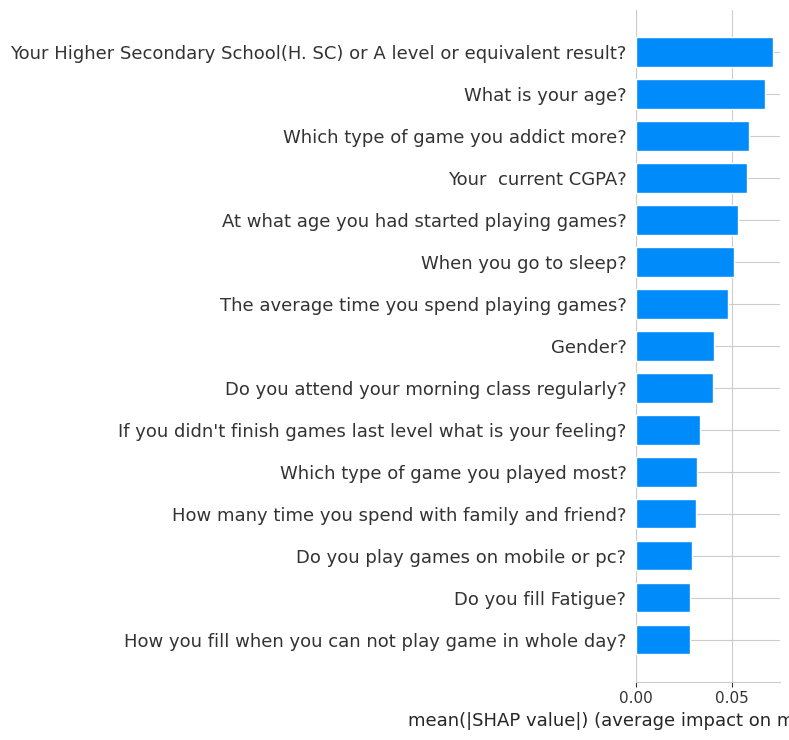


SHAP Beeswarm Plot (Feature Impact):


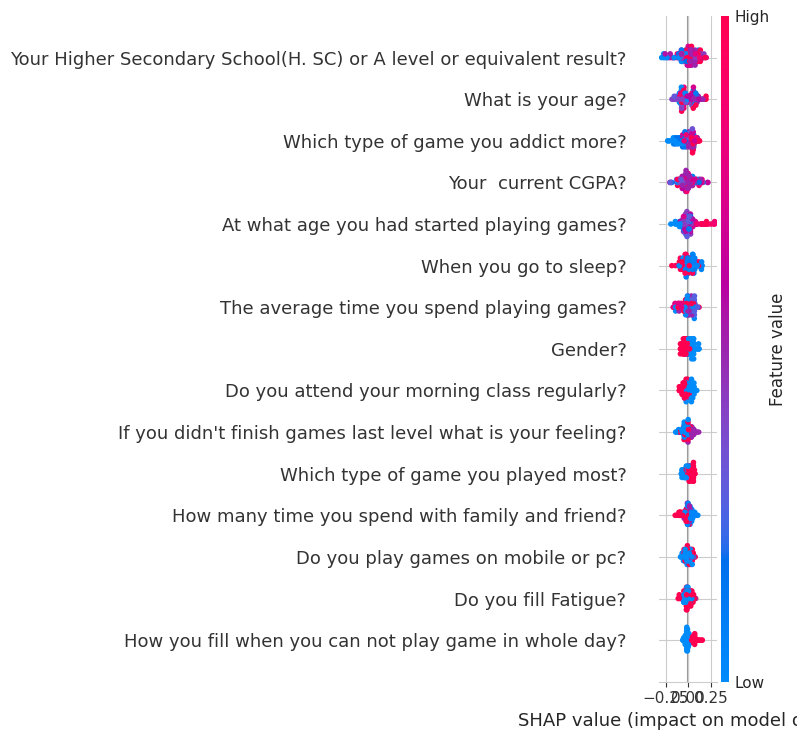


All analyses complete!


In [ ]:

if 'combined_importance' not in locals():
    print(" Please run Cell 11 (RQ4) first.")
else:
    # Top 15 features comparison across methods
    top_n = 15
    top_features = combined_importance.head(top_n)

    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=('Random Forest', 'Gradient Boosting', 'XGBoost',
                        'Permutation', 'SHAP', 'Combined Average'),
        vertical_spacing=0.15,
        horizontal_spacing=0.12
    )

    # RF
    fig.add_trace(
        go.Bar(y=top_features.index, x=top_features['RF'],
               orientation='h', marker_color='steelblue'),
        row=1, col=1
    )

    # GB
    fig.add_trace(
        go.Bar(y=top_features.index, x=top_features['GB'],
               orientation='h', marker_color='darkorange'),
        row=1, col=2
    )

    # XGB
    fig.add_trace(
        go.Bar(y=top_features.index, x=top_features['XGB'],
               orientation='h', marker_color='green'),
        row=1, col=3
    )

    # Permutation
    fig.add_trace(
        go.Bar(y=top_features.index, x=top_features['Perm'],
               orientation='h', marker_color='purple'),
        row=2, col=1
    )

    # SHAP
    fig.add_trace(
        go.Bar(y=top_features.index, x=top_features['SHAP'],
               orientation='h', marker_color='red'),
        row=2, col=2
    )

    # Combined
    fig.add_trace(
        go.Bar(y=top_features.index, x=top_features['Average'],
               orientation='h', marker_color='darkblue'),
        row=2, col=3
    )

    fig.update_yaxes(autorange="reversed")
    fig.update_layout(
        height=900,
        title_text=f"RQ4: Top {top_n} Feature Importance Comparison Across Methods",
        title_font_size=20,
        showlegend=False
    )

    try:
        fig.show()
    except Exception as e:
        print(f"Could not display plot: {e}")
        fig.write_html("rq4_feature_importance.html")

    # SHAP Summary Plot - Convert to DataFrame for compatibility
    print("\nSHAP Summary Plot:")
    X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

    try:
        shap.summary_plot(shap_values, X_test_df, plot_type="bar", max_display=15, show=False)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not display SHAP plot: {e}")

    # SHAP Beeswarm Plot
    print("\nSHAP Beeswarm Plot (Feature Impact):")
    try:
        shap.summary_plot(shap_values, X_test_df, max_display=15, show=False)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not display SHAP plot: {e}")

    print("\nAll analyses complete!")